# 🧪 Experiment EIC_073 — Composable Hybrid DLA Policies vs Baseline


## 📝 Introduction

In this experiment, we use the new `inventory.policies.hybrid_dla` module in a constant-demand inventory system.

We compare two composable hybrid motifs against the baseline heuristic `OrderUpToPolicy`:

- a **deterministic-lookahead hybrid** that combines a forecast provider, a mild terminal value correction, and a root proposal policy
- a **rollout-based hybrid** that uses the baseline as both proposal policy and continuation policy

This leads to the following guiding questions:

- ***RQ1*** – Can either composable hybrid policy outperform the simple fixed baseline heuristic `OrderUpToPolicy`?
- ***RQ2*** – How do deterministic lookahead and rollout-based lookahead differ in the actions they recommend?

To answer these questions, we follow our standard analytical workflow: define the problem, specify the policies, run strict-CRN evaluation, and then inspect both performance and action-level behavior.


## 📦 Imports

Here we define all required imports to conduct our experiment.

In [1]:
# Imports
import numpy as np

# Optional: in-notebook sanity check (no-op when installed)
from inventory.evaluation.notebooks.bootstrap import ensure_inventory_imports
ensure_inventory_imports(verbose=False)

# Evaluation
from inventory.evaluation import make_eval_info
from inventory.evaluation.reporting import summarize_totals

# Dynamic system framework
from inventory.core.dynamics import DynamicSystem

# Problem definitions
from inventory.problems.inventory_mvp import inventory_cost, inventory_cost_extended, inventory_transition, inventory_transition_capped_1d, inventory_cost_extended_capped

# Demand model (exogenous)
from inventory.problems.demand_models import PoissonConstantDemand

# Forecast providers
from inventory.forecasters import ConstantMeanPathForecaster
from inventory.forecasters.ml import MlDemandForecaster, ConstantFeatureAdapter
from inventory.forecasters.naive import ConstantMeanForecaster,NaiveForecaster

# Policies
from inventory.policies.baselines import OrderUpToPolicy
from inventory.policies.pfa import OrderUpToBlackboxPFA, OrderUpToStateDependentPFA, DirectActionPFA
from inventory.policies.vfa import FqiGreedyVfaPolicy, PostDecisionGreedyVfaPolicy, PostDecisionFittedGreedyVfaPolicy
from inventory.policies.hybrid_dla import (
    HybridDlaDeterministicComposablePolicy,
    HybridDlaRolloutComposablePolicy,
    InventoryLinearTerminalValue,
)


---

## 🚧 Problem definition

In this experiment we use our benchmark inventory problem with an constant Poisson demand and our standard set of cost parameters. Keeping this problem definition constant across experiments enables us to compare the effects of different policies.

In [2]:
# === Defining the dynamic system ===

# Simulation horizon
T = 30

# Initial Inventory
S0 = np.array([150.0], dtype=float)

# Constraints
x_max = 480
dx = 10
S_max = 480

# Exogenous demand
exo = PoissonConstantDemand(lam=300)

# Cost parameters 
p, c, h, b, K = 2.0, 0.5, 0.03, 1.0, 10.0

# Transition function
#transition_func = inventory_transition
transition_func = lambda s, a, w, t: inventory_transition_capped_1d(s, a, w, t, s_max=S_max)

# Cost functions
#cost_func = lambda s, a, w, t: inventory_cost(s, a, w, t, p=p, c=c, h=h, b=b)
#cost_func = lambda s, a, w, t: inventory_cost_extended(s, a, w, t, p=p, c=c, h=h, b=b, K=K)
cost_func = lambda s, a, w, t: inventory_cost_extended_capped(s, a, w, t, p=p, c=c, h=h, b=b, K=K, s_max=S_max)

# Dynamic System
system = DynamicSystem(
    transition_func=transition_func,
    cost_func=cost_func,
    exogenous_model=exo,
    sim_seed=42,
    d_s=1,
    d_x=1,
    d_w=1,
 )

# Strict-CRN Monte Carlo evaluation settings
seed0 = 1234
n_episodes = 200
eval_info = make_eval_info(T=T, det_mode='argmax')
eval_info

{'deterministic': True, 'det_mode': 'argmax', 'T': 30}

To get an idea about the kind of demand pattern we are dealing with in this problem setting, let us have a lookt at one expamplary demand that matches the CRN “reference episode” seed stream.

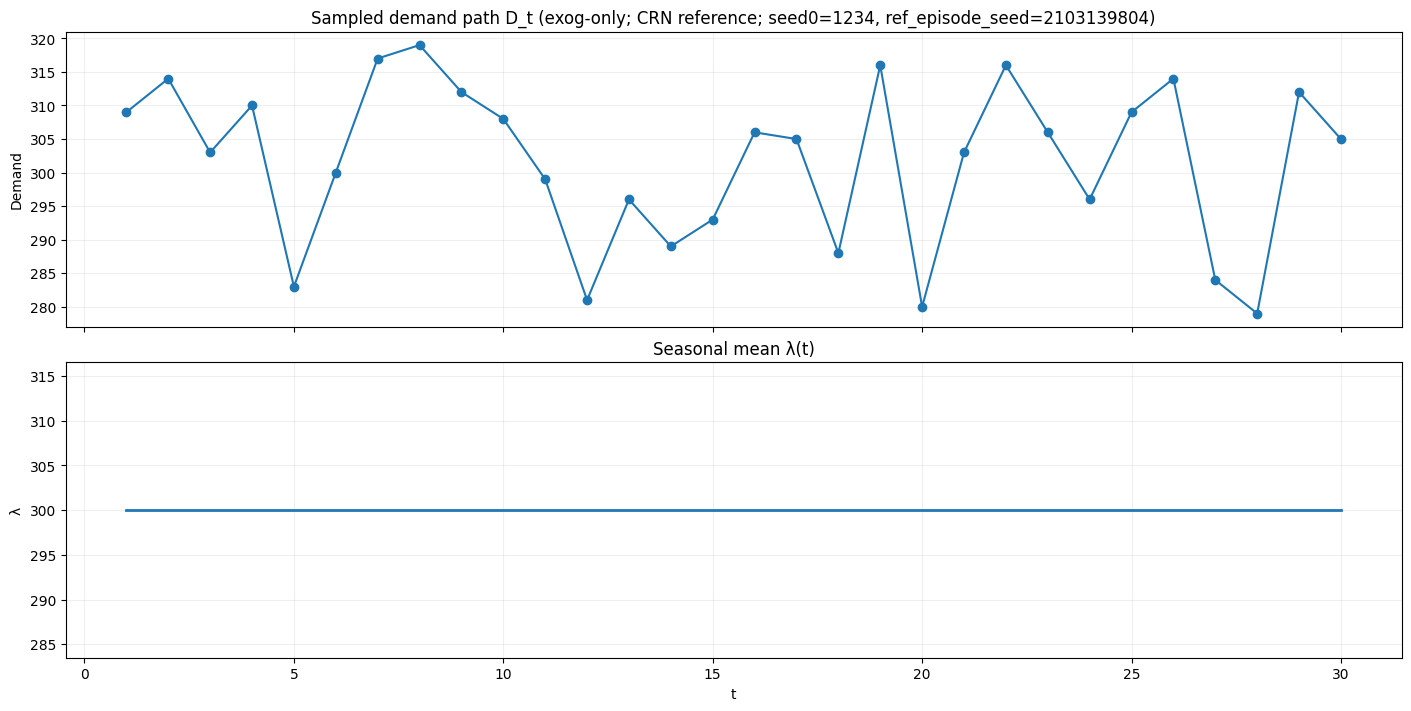

In [3]:
from inventory.evaluation.plotting import plot_seasonal_reference_episode_sample_path

_ = plot_seasonal_reference_episode_sample_path(
    exo,T,seed0=seed0,n_episodes=n_episodes,figsize=(14, 7),
    )

---

## 🔮 Forecaster defintion

In this section, we specify which information model (a.k.a. **forecaster**) the policy uses to anticipate future demand. Therefore we first instantiate the feature adapter for the respective exogenous model, second select the forecaster class with resptective paramenter settings, third, generate training and test data, and fourth, train the forecaster and plot its performance KPIs.

Next, we conclude with a short sanity check to ensure that the resulting predictions are reasonable before they are embedded into the policy.

In [4]:
# === Naive Forecaster ===
# Naive forecaster: repeat the last observed demand for the next H steps
forecaster_naive = NaiveForecaster(default_value=float(exo.lam))

# Print example prediction: Planned info payload passed into the CFA policy / forecaster call
naive_info_demo = {"last_demand": [295.0],}
H_demo = 5
mu_demo_naive = forecaster_naive.forecast_mean_path(S0, t=0, H=H_demo, info=naive_info_demo)
print("naive_info_demo:", naive_info_demo)
print(f"mu_demo_naive (H={H_demo}):", np.round(mu_demo_naive, 2))

naive_info_demo: {'last_demand': [295.0]}
mu_demo_naive (H=5): [295. 295. 295. 295. 295.]


In [5]:
# === Constants Forecaster ===
# Constant-demand forecaster: always predicts the exogenous `lam`
forecaster_const_300 = ConstantMeanForecaster(mean=float(exo.lam))

# Print example prediction: forecast mean demand path
H_demo = 5
mu_demo_const_300 = forecaster_const_300.forecast_mean_path(S0, t=0, H=H_demo)
print(f"mu_demo_const_300 (H={H_demo}):", np.round(mu_demo_const_300, 2))

mu_demo_const_300 (H=5): [300. 300. 300. 300. 300.]


In [6]:
# === ML Forecaster ===
# Here we use the `MlDemandForecaster` using `trees` with a `ConstantFeatureAdapter` to learn a simple constant demand model.
adapter = ConstantFeatureAdapter(exo)
forecaster_ml_tree = MlDemandForecaster(
    adapter, 
    model_type="tree", 
    tree_max_depth=6,
    min_samples_leaf=20,
    random_state=0)

# Train on synthetic data generated from the constant-demand exogenous model
fit_seed = 7
val_seed = 99

forecaster_ml_tree.fit_from_exogenous(
    n_samples=60000,
    seed=fit_seed,
    t_start=0,
    val_samples=1000,
    val_seed=val_seed,
    val_t_start=8000,
 )

# Print ML forecaster fit report summary
print("ML forecaster fit_report (summary):")
print("  model_type:", forecaster_ml_tree.fit_report.get("model_type"))
print("  feature_dim:", forecaster_ml_tree.fit_report.get("feature_dim"))
for split in ("train", "val"):
    rep = forecaster_ml_tree.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

# Print example prediction: forecast mean demand path
H_demo = 7
mu_demo = forecaster_ml_tree.forecast_mean_path(S0, t=0, H=H_demo)
print(f"\nmu_demo (H={H_demo}):", np.round(mu_demo, 2))

ML forecaster fit_report (summary):
  model_type: tree
  feature_dim: 1
  train: n=60000 | MAE=13.778 | RMSE=17.235 | Bias=0.000
  val: n=1000 | MAE=14.196 | RMSE=17.910 | Bias=-0.319

mu_demo (H=7): [299.98 299.98 299.98 299.98 299.98 299.98 299.98]


---

## 🤖 Policy definition

In this section, we define the policies under investigation and collect them in a policy dictionary used by our strict-CRN evaluation pipeline.

The first policy is the canonical benchmark `OrderUpTo`. The second policy is the main candidate that we want to compare against this benchmark. The third policy is a controlled variation of the candidate, included to examine one targeted variation of interest.

This set of policies enables a structured comparison and helps us address our research questions.

In [7]:
# === Baseline Policy ===
# Baseline: a fixed order-up-to target used both as a benchmark and as a simple root proposal policy.
baseline = OrderUpToPolicy(target_level=350.0, x_max=x_max, dx=dx)


### === DLA+Heuristic Hybrid ===

In [8]:
# === Deterministic composable hybrid ===
# This policy illustrates three explicit roles from hybrid_dla.py:
# 1) forecast_provider      -> a constant mean path forecaster
# 2) terminal_value_provider -> a mild linear continuation value in inventory
# 3) candidate_policy       -> the baseline policy narrows the root action set

forecast_provider_const = ConstantMeanPathForecaster(mu=float(exo.lam))
terminal_value_provider = InventoryLinearTerminalValue(theta0=0.0, theta1=0.05)

hybrid_deterministic = HybridDlaDeterministicComposablePolicy(
    system=system,
    forecast_provider=forecast_provider_const,
    terminal_value_provider=terminal_value_provider,
    candidate_policy=baseline,
    H=5,
    buffer_k=0.0, # no effect
    dx=dx,
    x_max=x_max,
    s_max=S_max,
    s_grid_step=dx,
    candidate_radius_steps=3,
    include_full_action_grid=False,
    p=p,
    c=c,
    h=h,
    b=b,
    K=K,
)


In [9]:
# === Rollout composable hybrid ===
# This policy keeps uncertainty explicit: it evaluates candidate first actions
# by simulation and then follows the rollout policy afterward.

hybrid_rollout = HybridDlaRolloutComposablePolicy(
    system=system,
    rollout_policy=baseline,
    candidate_policy=baseline,
    H=5,
    n_rollouts=30,
    dx=dx,
    x_max=x_max,
    decision_seed=2026,
    candidate_radius_steps=5,
    include_full_action_grid=False,
)


---

### === DLA+PFA Hybrid ===

In [10]:
# Train the candidate_policy
# Source: EIC_031_OrderUpToBlackboxPFA_vs_baseline.ipynb

# === Additional form of Candidate: DirectActionPFA (Decision Tree) ===
# Uses DirectActionPFA with a DecisionTreeRegressor.
# The decision tree learns a mapping from state features (inv, t) directly to
# the order quantity x — no order-up-to target level is computed.
# Training structure is identical to OrderUpToStateDependentPFA: rollout
# improvement generates supervised (state, best_action) labels.

from sklearn.tree import DecisionTreeRegressor

DirectActionPFA_Tree = DirectActionPFA(
    system=system,
    x_max=x_max,
    dx=dx,
    regressor=DecisionTreeRegressor(max_depth=4, random_state=seed0),
)

do_optimize = True
if do_optimize:
    DirectActionPFA_Tree.fit_via_rollout_improvement(
        S0=S0,
        T=T,
        n_episodes=n_episodes,
        seed0=seed0+5000,
        n_iter=3,
        info=eval_info,
    )

print(DirectActionPFA_Tree)

DirectActionPFA(regressor=DecisionTreeRegressor(max_depth=4, random_state=1234), x_max=480.0, dx=10, H=5, status=fitted)


In [11]:
# === Rollout composable hybrid ===
# This policy keeps uncertainty explicit: it evaluates candidate first actions
# by simulation and then follows the rollout policy afterward.

hybrid_rollout_pfa_tree = HybridDlaRolloutComposablePolicy(
    system=system,
    rollout_policy=DirectActionPFA_Tree,
    candidate_policy=DirectActionPFA_Tree,
    H=5,
    n_rollouts=30,
    dx=dx,
    x_max=x_max,
    decision_seed=2026,
    candidate_radius_steps=5,
    include_full_action_grid=False,
)


---

### === DLA+VFA Hybrid ===

In [12]:
# === Candidate Policy ===
# Source: EIC_052c_VfaPolicy_vs_baseline.ipynb
# Candidate: FQI is a batch method that collects transitions under a behavior policy, fits a Q surrogate on Bellman backup targets, and then acts greedily online.

# Select policy profile to trade off speed vs quality:
profile = "fast"  # "fast" | "quality"

if profile == "fast":
    train_episodes = 100#250
    n_iterations = 4#8
    gamma = 0.97
    ridge_alpha = 50.0
    behavior = "random"
    eps_behavior = 0.20
    tree_max_depth = 3
    tree_max_iter = 80
    tree_min_samples_leaf = 30


elif profile == "quality":
    train_episodes = 1000
    n_iterations = 12
    gamma = 0.98
    ridge_alpha = 50.0  # Keep ridge moderate; much larger values can collapse poly2 into a linear-like greedy policy.
    behavior = "egreedy"  # More focused data collection: epsilon-greedy w.r.t. the current Q-hat.
    eps_behavior = 0.20
    tree_max_depth = 4
    tree_max_iter = 200
    tree_min_samples_leaf = 20
else:
    raise ValueError("profile must be 'fast' or 'quality'")


# Define the candidate policy with scaled raw features for numerical stability.
feature = "linear"  # "linear" or "poly2"
inv_scale = 300.0
a_scale = 200.0
train_seed0 = 2026

candidate = FqiGreedyVfaPolicy(
    model=system,
    gamma=float(gamma),
    x_max=float(x_max),
    dx=int(dx),
    mode="tree",
    ridge_alpha=float(ridge_alpha),
    feature=str(feature),
    random_state=0,
    inv_scale=float(inv_scale),
    a_scale=float(a_scale),
    tree_max_depth=int(tree_max_depth),
    tree_max_iter=int(tree_max_iter),
    tree_min_samples_leaf=int(tree_min_samples_leaf),
)

# Train the candidate policy using FQI learning
# FQI is more stable than TD learning, so we do not sweep learning rates here.

candidate.train_fqi(
    S0=S0,
    T=T,
    n_episodes=int(train_episodes),
    seed0=int(train_seed0),
    n_iterations=int(n_iterations),
    behavior=str(behavior),
    eps_behavior=float(eps_behavior),
)

# Take best training candidate as final candidate for evaluation
FqiGreedyVfa_tree = candidate

# Print training results and sanity checks
print("=== FQI training complete ===")
print("  profile:", profile)
print("  behavior:", behavior, "(eps=", float(eps_behavior), ")")
print("  mode:", candidate.mode)
print("  feature:", candidate.feature)
print("  gamma:", candidate.gamma)
print("  ridge_alpha:", candidate.ridge_alpha)
print("  inv_scale:", candidate.inv_scale)
print("  a_scale:", candidate.a_scale)
print("  train_episodes:", int(train_episodes))
print("  n_iterations:", int(n_iterations))
print("  q_model:", type(candidate.q_model).__name__ if candidate.q_model is not None else None)


=== FQI training complete ===
  profile: fast
  behavior: random (eps= 0.2 )
  mode: tree
  feature: linear
  gamma: 0.97
  ridge_alpha: 50.0
  inv_scale: 300.0
  a_scale: 200.0
  train_episodes: 100
  n_iterations: 4
  q_model: HistGradientBoostingRegressor


In [13]:
# === Rollout composable hybrid ===
# This policy keeps uncertainty explicit: it evaluates candidate first actions
# by simulation and then follows the rollout policy afterward.

hybrid_rollout_vfa_fqi = HybridDlaRolloutComposablePolicy(
    system=system,
    rollout_policy=DirectActionPFA_Tree,
    candidate_policy=FqiGreedyVfa_tree,
    H=3,
    n_rollouts=10,
    dx=dx,
    x_max=x_max,
    decision_seed=2026,
    candidate_radius_steps=1,
    include_full_action_grid=False,
)

---

In [14]:
# === Collect policies into a dictionary for easy access in evaluation/reporting code ===
policies = {
    'OrderUpTo_350': baseline,
    'hybrid_deterministic_heuristic': hybrid_deterministic,
    'hybrid_rollout_heuristic': hybrid_rollout,
    'hybrid_rollout_pfa_tree': hybrid_rollout_pfa_tree,
    'hybrid_rollout_vfa_fqi': hybrid_rollout_vfa_fqi,
}

print('==== Policy Parameters ====')
policies


==== Policy Parameters ====


{'OrderUpTo_350': OrderUpToPolicy(target_level=350.0, x_max=480, dx=10),
 'hybrid_deterministic_heuristic': HybridDlaDeterministicComposablePolicy(forecast_provider='ConstantMeanPathForecaster', terminal_value_provider='InventoryLinearTerminalValue', candidate_policy='OrderUpToPolicy', H=5, buffer_k=0.0, dx=10, x_max=480, s_max=480, s_grid_step=10, candidate_radius_steps=3, include_full_action_grid=False, p=2.0, c=0.5, h=0.03, b=1.0, K=10.0),
 'hybrid_rollout_heuristic': HybridDlaRolloutComposablePolicy(rollout_policy='OrderUpToPolicy', candidate_policy='OrderUpToPolicy', H=5, n_rollouts=30, dx=10, x_max=480, decision_seed=2026, candidate_radius_steps=5, include_full_action_grid=False, adaptive_candidate_radius=False, adaptive_radius_near=2, adaptive_radius_far=8, adaptive_gap_threshold=40.0, rollout_history_window=0),
 'hybrid_rollout_pfa_tree': HybridDlaRolloutComposablePolicy(rollout_policy='DirectActionPFA', candidate_policy='DirectActionPFA', H=5, n_rollouts=30, dx=10, x_max=480, 

---

## 🪄 Experiment run and Strict-CRN policy evaluation

In this section, we evaluate all policies under identical sampled exogenous paths using strict CRN. This ensures a fair comparison and allows us to summarize and illustrate the resulting performance differences.

In [15]:
# === Experiment run and Strict-CRN policy evaluation ===
from inventory.evaluation.notebooks.crn_runs import run_crn_mc

run = run_crn_mc(
    system=system,
    policies=policies,
    S0=S0,
    T=T,
    n_episodes=n_episodes,
    seed0=seed0,
    info=eval_info,
    print_summary=True,
)

results = run.results
rollouts = run.rollouts
totals_by_policy = run.totals_by_policy
totals_summary = run.totals_summary

=== Final CRN-MC totals (lower is better) ===
OrderUpTo_350   | mean=-13208.711 | std=141.949 | n=200 | runtime=0.085s
hybrid_deterministic_heuristic | mean=-13166.466 | std=122.629 | n=200 | runtime=2.637s
hybrid_rollout_heuristic | mean=-13212.659 | std=139.180 | n=200 | runtime=93.540s
hybrid_rollout_pfa_tree | mean=-13198.101 | std=137.848 | n=200 | runtime=315.078s
hybrid_rollout_vfa_fqi | mean=-13177.746 | std=146.001 | n=200 | runtime=28.458s


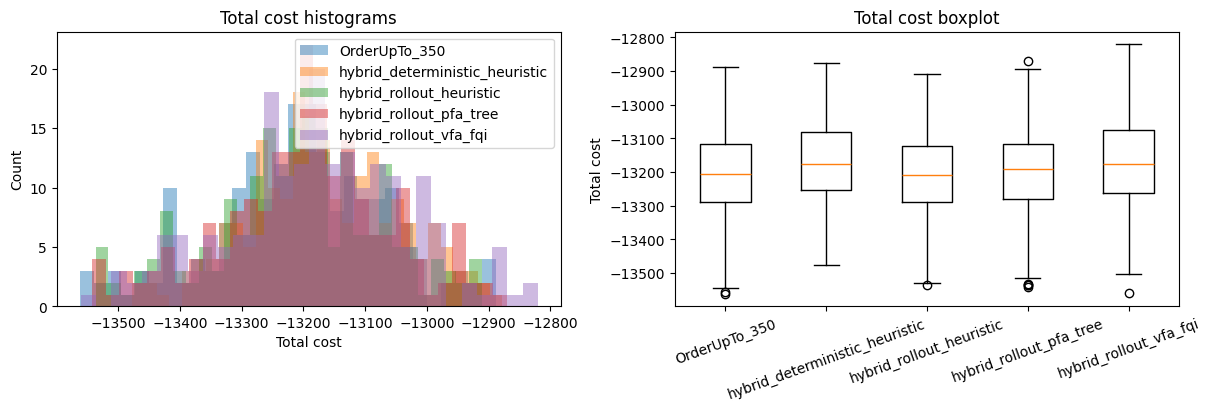

In [16]:
# === Plot total cost distribution and boxplot ===
from inventory.evaluation.plotting import plot_totals_hist_and_box
_ =plot_totals_hist_and_box(totals_by_policy)

---

## 🔬 Results, Insights & Discussion

In this section, we summarize and interpret the main findings of the experiment in a research-paper style. We first present the key results in compact form, using a result table and a main comparison plot to highlight overall performance differences.

We then discuss what these results teach us by interpreting the baseline–candidate comparison, the default–variation comparison within the candidate class, and their relevance for the underlying modeling question.

Based on this, we answer the research questions directly and conclude with implications and possible next steps.

### What are the main results?
- compact result table
- one main comparison plot
- short interpretation of who performs best
- ***Results 1***: 

### What do we learn?
- interpret baseline vs candidate
- interpret candidate default vs candidate variation
- connect result back to the modeling question
- ***Learning 1***: 

### How would we answer our reseach questions?
- ***RQ1***: 
- ***RQ2***: 

### What next steps would we plan?
- Address implications and next steps
- ***Next step1***:


---

## 🥊 Punchline

In this section, we distill the main punchline of the experiment into an exam-relevant takeaway. Think of it as the “if you remember only two things, remember these” message.


- ***Takeaway 1***: Lorem ipsum

- ***Takeaway 2***: Dolor sit 

---

# Appendix

## 🏎️ Appendix A: Dynamics of the system under policy regimes

In this section, we study the dynamics of the system under the different policy regimes. We first inspect one strict-CRN trajectory for all three policies to compare their actions and resulting system behavior. We then visualize many trajectories together with their mean paths to identify broader dynamic patterns.

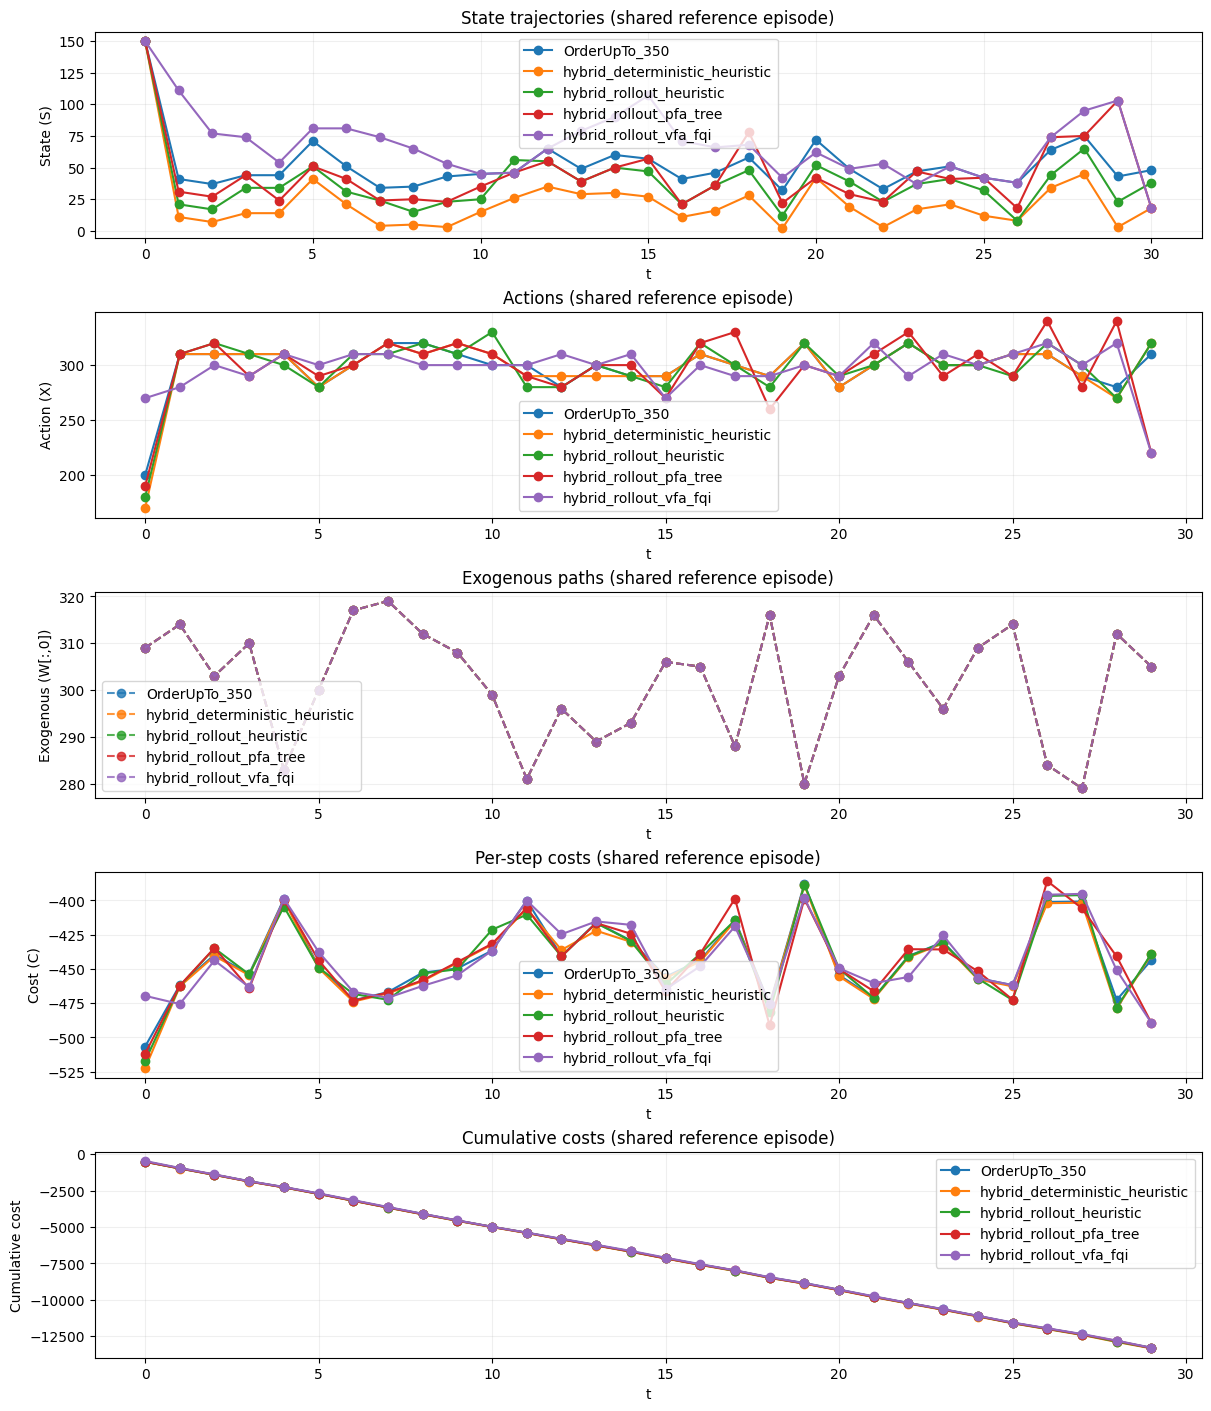

In [31]:
# === Visual dynamics for one shared *reference episode* per policy ===
from inventory.evaluation.plotting import plot_reference_episode_rollouts_grid
_ = plot_reference_episode_rollouts_grid(
    rollouts,
    figsize=(12, 14),
    show=True,
    marker="o",
 )

In [ ]:
# === Visual dynamics across many episodes (overlay: faint lines = episodes, bold line = mean) ===

n_plot_episodes = 50

rollouts_mc = system.collect_policies_crn_rollouts_mc(
    policies,
    S0,
    T=T,
    n_episodes=n_plot_episodes,
    seed0=seed0,
    info=eval_info,
 )

from inventory.evaluation.plotting import plot_rollouts_overlay_grid
_ = plot_rollouts_overlay_grid(
    rollouts_mc,
    figsize=(12, 14),
    alpha_episode=0.12,
    linewidth_episode=1.0,
    linewidth_mean=2.8,
    title_suffix=f"(CRN-MC overlay; n={n_plot_episodes})",
    show=True,
 )

---

## 📈 Appendix B: Statistical validation

In this section, we statistically compare the baseline policy against **one focal hybrid policy at a time**.

Because this notebook now contains more than one hybrid policy, the summary above should be read first. The paired-delta appendix below then lets us choose one treatment policy explicitly via `focal_policy_name` in the next code cell.

Given the hypothesis of interest, we define the paired-delta direction, compute the paired differences, and assess their normality. We then use these paired deltas to perform both a frequentist and a Bayesian hypothesis test.

Finally, we summarize the findings and interpret their meaning in context.

**Notes**

- This appendix supports the statistical comparison of **two** policies only. Multi-policy comparisons require different assumptions and a separate method, which is not implemented here.
- The frequentist and Bayesian hypotheses may differ slightly. They are stated explicitly in their respective sections.


### ⚖️ Paired Delta analysis

Our default hypothesis of interest is that the treatment policy has a positive effect, that is, it achieves a **lower total cost** than the control policy. We therefore compute the paired deltas in the corresponding direction and examine their distribution using a normality diagnostic. This prepares the ground for the subsequent frequentist and Bayesian analyses.


In [ ]:
# === Get paired deltas summary ===
from inventory.evaluation.notebooks.reports import print_paired_delta_summary

reports = print_paired_delta_summary(
    totals_by_policy,
    baseline_name="baseline",
    higher_is_better=False,
)

In [41]:
# === Calculate paired deltas ===
from inventory.evaluation.notebooks.reports import compute_crn_deltas

# Note: the "other_policy" argument controls which paired deltas are computed (e.g. candidate vs. candidate_var)
crn_deltas = compute_crn_deltas(
    totals_by_policy,
    #base_policy="baseline",
    #other_policy="candidate",
    base_policy="hybrid_rollout_vfa_fqi",
    other_policy="OrderUpTo_350",
    plot=False,
)

=== Normality Diagnostics ===
Statistics: n=200, mean=-30.97, std=22.54
Shapiro–Wilk:       stat=0.9721, p=0.0005111
D’Agostino–Pearson: stat=9.3921, p=0.009131
=== Decision at α = 0.05 ===
- At least one test rejects strict normality.
- With n ≈ 1000, even tiny deviations from normality become significant.
- For inference on the mean delta, t-tests/CLT reasoning is often still fine.


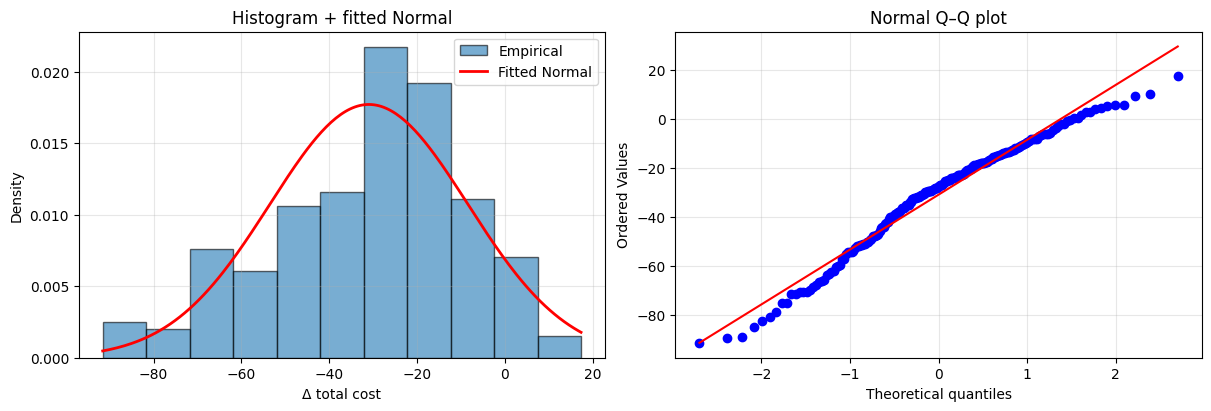

In [42]:
# === Normality diagnostics for paired deltas ===
from inventory.evaluation.deltas import normality_diagnostics
_ = normality_diagnostics(crn_deltas)

---

### ⏱️ Frequentist analysis
In this section, we analyze the policy comparison from a frequentist perspective. Based on the paired deltas, we test whether the observed performance difference is statistically significant under the hypothesis of interest.

Depending on the distribution of the paired differences, we apply an appropriate test and interpret the resulting p-value, test statistic, and confidence interval.

In [43]:
# === Frequentist evaluation of CRN deltas ===
from inventory.evaluation.notebooks.reports import print_frequentist_report_for_crn_deltas

_ = print_frequentist_report_for_crn_deltas(crn_deltas)

=== Frequentist CRN Paired-Delta Analysis (Treatment=B vs Control=A) ===
Objective: cost | Delta convention: treatment-control
Delta definition: Δ = Treatment - Control (B - A)
Direction: B better than A ⇔ Δ < 0 | Win-rate rule: B better ⇔ Δ < 0
Claim: B better than A (one-sided, pre-specified)
Alternative used: less | alpha=0.050

--- Hypotheses ---
H0: E[Δ] = 0  (no average difference)
H1: E[Δ] < 0  (B better than A, because B better ⇔ Δ < 0)

--- Descriptives (deltas) ---
n=200 | mean=-30.9655 | median=-27.6000 | std=22.5390 | dz=-1.3739
min=-91.6000 | max=17.3700
win rate (B beats A)=0.9350 (wins=187, losses=13, ties=0)

--- Normality check (Shapiro on deltas) ---
stat=0.9721 | p=0.0005 | reject@0.050=True

--- Hypothesis tests ---
Paired t-test (Δ vs 0): t=-19.4294 (df=199) | p=0.0000 (<1e-4) | CI(mean)=[-34.1083, -27.8227]
Wilcoxon: W=221.5000 | p=0.0000 (<1e-4)
Sign test: p=0.0000 (<1e-4) | n_eff=200 (zeros ignored)
Permutation (sign-flip mean): p=0.0000 (<1e-4) (n_perm=20000)



### 🔬 Insights

***Frequentist Analysis***

- **Hypothesis**: Here, we formulate the frequentist null and alternative hypotheses for the paired policy comparison.

- **Results**: Here, we report the main outputs of the frequentist test, including the test statistic, p-value, and confidence interval.

- **Interpretation**: Here, we interpret the frequentist results and relate them back to the original policy question.

---

### 🎰 Bayesian analysis
In this section, we examine the policy comparison from a Bayesian perspective. Based on the paired deltas, we estimate the probability that one policy outperforms the other and quantify the uncertainty around the effect. the goal is to assess how credible the observed performance advantage is, how large the effect is likely to be, and what this implies for our decision-making problem.

This complements the frequentist view by focusing on credible effect sizes and probabilistic interpretation rather than statistical significance alone.

In [44]:
# === Bayesian evaluation of CRN deltas ===
from inventory.evaluation.notebooks.reports import print_bayesian_report_for_crn_deltas

print_bayesian_report_for_crn_deltas(
    crn_deltas,
    better="lower",
    deltas_are="B_minus_A",
    random_state=0,
    n_draws=200_000,
    cred_level=0.95,
    delta=50.0,
    rope=0.05,
    mode="full",
)

Decision @ 0.95: NO PASS —   P(E[B-A] <= -50) = 0.000
-----------------------------------------------------
Bayesian Policy Comparison (paired CRN, episode TOTAL cost)
n episodes: 200
Interpretation: deltas = B - A

Data summary (deltas = B-A):
  sample mean: -30.9655
  sample sd  :  22.539
  min / max  : -91.6 /  17.37

Posterior on mean treatment effect (E[B-A]):
  95.0% CrI: [-34.1308, -27.9209]
  P(E[B-A] < 0): 1.000
  P(E[B-A] <= -50): 0.000
  ROPE ±0.05: P(|E[B-A]|<=rope) = 0.000

Verdict:
  Weak/insufficient evidence: P(E[B-A] <= -50) = 0.000


### 🔬 Insights

***Bayesian Analysis***

- **Hypothesis**: Here, we formulate the Bayesian hypothesis of interest for the paired policy comparison.
- **Results**: Here, we summarize the posterior results, including credible intervals and the probability that one policy outperforms the other.
- **Interpretation**: Here, we interpret the Bayesian findings and discuss what they imply for the policy comparison.

---

## 🚀 Appendix C: Further variatons

In this section, you can explore further variations of the candidate policy to generate additional insights.

To proceed, copy the **Policy Definition** section, modify the policy as needed, and rerun the evaluation pipeline. If appropriate, you may also use the appendices to support a deeper analysis of the new variation.

### 🤖 🪄Additional Policy definition

In [ ]:
# === Copy and adjust 🤖 🪄Additional Policy definition section here ===

### 🪄Additional Experiment run and Strict-CRN policy evaluation

In [ ]:
# === Copy and run 🤖 🪄Additional Experiment run and Strict-CRN policy evaluationsection here ===

### 🏎️ Additional Appendix A: Dynamics of the system under policy regimes section

In [ ]:
# === Copy and run 🏎️ Appendix A: Dynamics of the system under policy regimes section here ===

### 🔍 Additional Appendix B: Statistical validation section 

In [ ]:
# === Copy and run 🔍 Appendix B: Statistical validation section here ===

### 🔬 Additional Insights

In [ ]:
# === Insert 🔬 Additional Insights here ===

---

---

## 🔮 Appendix D: Information model definition

In this section, we specify (if relevant) which information model the policy uses to anticipate future demand. We begin by formulating the forecasting task and explaining why a forecast is needed in this setting. We then describe the training data, including the features and labels used for learning.

Next, we train the selected forecaster variants and conclude with a short sanity check to ensure that the resulting predictions are reasonable before they are embedded into the policy.

In [ ]:
# === Forecasting task ===
# - what is being predicted?
# - why is forecasting needed here?

In [ ]:
# === Forecaster training data & training ===
# - where the data comes from
# - short explanation of features and labels

# - fit constant / linear / GBDT / MLP / quantile forecaster

In [ ]:
# === Forecaster sanity check ===
# - small plot or a few example predictions

---